# 📊 01 — Data Understanding
## Insurance Retention Analytics

> **Objetivo de este notebook:** Realizar la primera lectura del dataset, validar su integridad y formular hipótesis iniciales sobre los drivers del churn que serán contrastadas en notebooks posteriores.

**Fase CRISP-DM:** Data Understanding    
**Fecha:** 2026

---

## Tabla de contenidos

1. [Contexto del problema de negocio](#1-contexto)
2. [Carga del dataset](#2-carga)
3. [Inspección estructural](#3-estructura)
4. [Calidad de datos](#4-calidad)
5. [Variable objetivo (`churn_flag`)](#5-target)
6. [Primer perfilado de variables](#6-perfilado)
7. [Hipótesis iniciales](#7-hipotesis)
8. [Conclusión ejecutiva](#8-conclusion)

---

<a id="1-contexto"></a>
## 1. Contexto del problema de negocio

Una aseguradora de tamaño medio observa una **tasa de no renovación (churn) cercana al 30%** en su cartera. Esto implica:

- **Pérdida directa de prima recurrente** (revenue churn).
- **Mayor costo de adquisición** (CAC > 5× costo de retención).
- **Deterioro del Customer Lifetime Value (CLV)**.

El área de **Retention & CX** requiere responder tres preguntas:

| Pregunta | Tipo de análisis | Notebook |
|---|---|---|
| ¿Quién abandona y por qué? | Descriptivo | `02_eda` |
| ¿Podemos predecirlo antes de que ocurra? | Predictivo | `04_ml` |
| ¿Qué acciones priorizar? | Prescriptivo | `07_business_insights` |

Este notebook (`01`) sienta las bases: entender qué dato tenemos antes de tocarlo.

<a id="2-carga"></a>
## 2. Carga del dataset

**Buena práctica:** usar rutas **relativas** desde `notebooks/` hacia `data/raw/`. Esto hace que el proyecto sea reproducible en cualquier equipo (Windows, Mac, Linux) sin modificar el código.

In [1]:
# ============================================================
# Imports y configuración global
# ============================================================
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Versiones — útil para reproducibilidad
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")

pandas  : 2.1.4
numpy   : 1.26.4


In [2]:
# ============================================================
# Carga del dataset
# Ruta relativa: este notebook vive en /notebooks, el CSV en /data/raw
# ============================================================
DATA_PATH = Path("../data/raw/insurance_policyholder_churn_synthetic.csv")

df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset cargado correctamente desde: {DATA_PATH}")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

✅ Dataset cargado correctamente desde: ..\data\raw\insurance_policyholder_churn_synthetic.csv
   Filas    : 50,000
   Columnas : 40


<a id="3-estructura"></a>
## 3. Inspección estructural

Antes de analizar, validamos:
- **Dimensiones** del dataset
- **Tipos de dato** por columna (numéricas vs categóricas)
- **Muestra** de los primeros registros para entender granularidad

> 💡 **Granularidad esperada:** 1 fila = 1 cliente en una fecha de corte (`as_of_date`). Esto significa que cada `customer_id` debería aparecer una sola vez.

In [3]:
# Primeras filas
df.head()

,customer_id,as_of_date,region_name,age,age_band,marital_status,customer_tenure_months,multi_policy_flag,num_policies,policy_type,renewal_month,current_premium,premium_last_year,premium_change_pct,num_price_increases_last_3y,coverage_amount,premium_to_coverage_ratio,payment_frequency,autopay_enabled,late_payment_count_12m,missed_payment_flag,payment_method_change_flag,num_claims_12m,num_approved_claims_12m,num_rejected_claims_12m,num_pending_claims_12m,avg_claim_amount,total_claim_amount_12m,total_payout_amount_12m,payout_ratio_12m,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,churn_flag,churn_type,churn_probability_true
0,1,2025-12-31,Manawatu-Whanganui,24,18-24,Married,128,1,4,Auto,8,"1,013.47","1,060.04",-0.04,1,"8,924.09",0.11,Monthly,1,0,0,0,0,0,0,0,"5,250.19",0.00,0.00,0.75,7,1616,0,0,0,0,0,0,No churn,0.05
1,2,2025-12-31,Auckland,70,65-74,Married,76,1,3,Auto,3,"1,126.90","1,052.27",0.05,2,"43,734.45",0.03,Monthly,1,0,0,0,0,0,0,0,"4,141.41",0.00,0.00,0.75,15,1760,1,0,0,0,0,0,No churn,0.07
2,3,2025-12-31,Bay of Plenty,62,55-64,Married,129,0,1,Auto,5,984.70,874.29,0.12,1,"23,152.37",0.04,Annual,0,0,0,0,0,0,0,0,"1,956.42",0.00,0.00,0.75,24,1581,1,0,0,0,0,0,No churn,0.22
3,4,2025-12-31,Bay of Plenty,47,45-54,Single,104,0,1,Auto,2,373.61,331.99,0.15,2,"31,806.95",0.01,Monthly,1,2,0,0,0,0,0,0,"3,204.54",0.00,0.00,0.75,17,1688,1,0,0,0,0,0,No churn,0.60
4,5,2025-12-31,Bay of Plenty,47,45-54,Married,22,1,3,Life,11,974.18,991.82,0.02,1,"302,831.02",0.00,Monthly,1,0,0,0,0,0,0,0,"52,392.59",0.00,0.00,0.85,24,1592,1,0,0,0,0,0,No churn,0.05


In [4]:
# Tipos de dato y memoria
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_p

In [5]:
# Validar granularidad: ¿customer_id es único?
n_total  = len(df)
n_unique = df["customer_id"].nunique()

print(f"Total de filas        : {n_total:,}")
print(f"customer_id únicos    : {n_unique:,}")
print(f"¿Granularidad OK?     : {'✅ Sí' if n_total == n_unique else '❌ No, hay duplicados'}")

Total de filas        : 50,000
customer_id únicos    : 50,000
¿Granularidad OK?     : ✅ Sí


<a id="4-calidad"></a>
## 4. Calidad de datos

Chequeos básicos que **siempre** se hacen al inicio de un proyecto:

1. **Valores nulos** por columna
2. **Duplicados** (filas idénticas)
3. **Tipos inesperados** (e.g. fechas como string, flags no binarios)
4. **Rangos sospechosos** (edades negativas, premium = 0, etc.)

In [6]:
# 4.1 — Valores nulos
nulos     = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

calidad_nulos = (
    pd.DataFrame({"n_nulos": nulos, "%_nulos": nulos_pct})
    .query("n_nulos > 0")
    .sort_values("n_nulos", ascending=False)
)

if calidad_nulos.empty:
    print("✅ No hay valores nulos en ninguna columna.")
else:
    print("⚠️  Columnas con valores nulos:")
    display(calidad_nulos)

✅ No hay valores nulos en ninguna columna.


In [7]:
# 4.2 — Duplicados completos
n_dup = df.duplicated().sum()
print(f"Filas duplicadas: {n_dup}")
print("✅ OK" if n_dup == 0 else "⚠️  Hay que tratarlos en data prep")

Filas duplicadas: 0
✅ OK


In [8]:
# 4.3 — Rangos sospechosos en variables clave
chequeos = {
    "age"                     : (df["age"].min(), df["age"].max()),
    "customer_tenure_months"  : (df["customer_tenure_months"].min(), df["customer_tenure_months"].max()),
    "current_premium"         : (df["current_premium"].min(), df["current_premium"].max()),
    "premium_change_pct"      : (df["premium_change_pct"].min(), df["premium_change_pct"].max()),
    "num_policies"            : (df["num_policies"].min(), df["num_policies"].max()),
}

print(f"{'Variable':<30} {'Min':>15} {'Max':>15}")
print("-" * 62)
for var, (mn, mx) in chequeos.items():
    print(f"{var:<30} {mn:>15,.2f} {mx:>15,.2f}")

Variable                                   Min             Max
--------------------------------------------------------------
age                                      18.00           85.00
customer_tenure_months                    1.00          180.00
current_premium                         120.00        3,348.35
premium_change_pct                       -0.16            0.41
num_policies                              1.00            4.00


<a id="5-target"></a>
## 5. Variable objetivo: `churn_flag`

Esta es la variable que el modelo aprenderá a predecir. Necesitamos saber:

- **Su distribución**: ¿está balanceada o desbalanceada?
- **La tasa base de churn** (será nuestra referencia para evaluar el modelo)
- **Por qué importa el balance**: si el 95% es clase 0, un modelo "tonto" que prediga siempre 0 tendría 95% accuracy pero sería inservible para el negocio.

> 📌 **Concepto clave:** en clasificación, cuando una clase domina (>70%) hablamos de **dataset desbalanceado**. Esto obliga a:
> - No usar accuracy como única métrica → usar **F1, Recall, Precision**.
> - Considerar técnicas como `scale_pos_weight` (XGBoost) o `class_weight` (sklearn).

In [9]:
# 5.1 — Distribución del target
distribucion = df["churn_flag"].value_counts().to_frame(name="n_clientes")
distribucion["porcentaje"] = (distribucion["n_clientes"] / len(df) * 100).round(2)
distribucion.index = ["Retenido (0)", "Churn (1)"]

display(distribucion)

churn_rate = df["churn_flag"].mean() * 100
ratio_des  = (1 - df["churn_flag"].mean()) / df["churn_flag"].mean()
print(f"\n🎯 Tasa base de churn: {churn_rate:.2f}%")
print(f"⚖️  Ratio de desbalance: 1:{ratio_des:.2f}")

,n_clientes,porcentaje
Retenido (0),34917,69.83
Churn (1),15083,30.17



🎯 Tasa base de churn: 30.17%
⚖️  Ratio de desbalance: 1:2.31


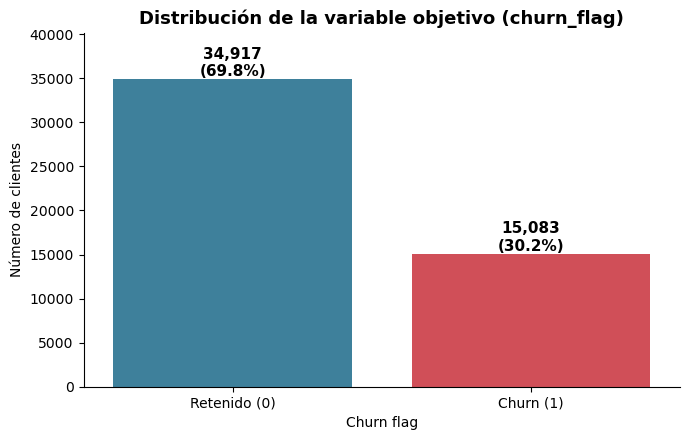

In [10]:
# 5.2 — Visualización de la distribución
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta consistente del proyecto
PALETTE = {"retained": "#2E86AB", "churn": "#E63946"}

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(
    x="churn_flag",
    data=df,
    palette=[PALETTE["retained"], PALETTE["churn"]],
    ax=ax
)

# Anotaciones encima de cada barra
total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(
        f"{int(p.get_height()):,}\n({pct:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Distribución de la variable objetivo (churn_flag)", fontsize=13, fontweight="bold")
ax.set_xlabel("Churn flag")
ax.set_ylabel("Número de clientes")
ax.set_xticklabels(["Retenido (0)", "Churn (1)"])
ax.set_ylim(0, df["churn_flag"].value_counts().max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación del gráfico:**

- ✅ El dataset está **moderadamente desbalanceado** (70/30), no es un caso extremo.
- ✅ El 30% de churn es **realista para una aseguradora** (los estudios sectoriales reportan tasas entre 10–25% en aseguradoras maduras y hasta 30%+ en aseguradoras jóvenes o de auto).
- ⚠️  No usaremos accuracy como única métrica. Privilegiaremos **F1-score** y **Recall** sobre la clase churn, ya que el costo de no detectar un cliente que abandona (FN) suele ser mayor que el de contactar a uno que no lo iba a hacer (FP).

<a id="6-perfilado"></a>
## 6. Primer perfilado de variables

Clasificamos las 40 columnas por **familia** y obtenemos estadísticas básicas. Esto guiará el EDA del notebook 02.

In [11]:
# 6.1 — Familias de variables (mapeo de negocio)
familias = {
    "Identificador / Tiempo": ["customer_id", "as_of_date"],
    "Demográficas":           ["region_name", "age", "age_band", "marital_status"],
    "Pólizas":                ["customer_tenure_months", "multi_policy_flag", "num_policies",
                               "policy_type", "renewal_month"],
    "Económicas":             ["current_premium", "premium_last_year", "premium_change_pct",
                               "num_price_increases_last_3y", "coverage_amount",
                               "premium_to_coverage_ratio"],
    "Comportamiento de pago": ["payment_frequency", "autopay_enabled", "late_payment_count_12m",
                               "missed_payment_flag", "payment_method_change_flag"],
    "Siniestros (claims)":    ["num_claims_12m", "num_approved_claims_12m",
                               "num_rejected_claims_12m", "num_pending_claims_12m",
                               "avg_claim_amount", "total_claim_amount_12m",
                               "total_payout_amount_12m", "payout_ratio_12m",
                               "avg_settlement_time_days", "days_since_last_claim"],
    "Servicio al cliente":    ["num_contacts_12m", "complaint_flag", "complaint_resolution_days"],
    "Señales de fuga":        ["quote_requested_flag", "coverage_downgrade_flag"],
    "Target":                 ["churn_flag", "churn_type", "churn_probability_true"],
}

print("📦 Mapeo de variables por familia de negocio")
print("=" * 60)
for fam, cols in familias.items():
    print(f"\n{fam} ({len(cols)} variables):")
    for c in cols:
        print(f"   • {c}")

📦 Mapeo de variables por familia de negocio

Identificador / Tiempo (2 variables):
   • customer_id
   • as_of_date

Demográficas (4 variables):
   • region_name
   • age
   • age_band
   • marital_status

Pólizas (5 variables):
   • customer_tenure_months
   • multi_policy_flag
   • num_policies
   • policy_type
   • renewal_month

Económicas (6 variables):
   • current_premium
   • premium_last_year
   • premium_change_pct
   • num_price_increases_last_3y
   • coverage_amount
   • premium_to_coverage_ratio

Comportamiento de pago (5 variables):
   • payment_frequency
   • autopay_enabled
   • late_payment_count_12m
   • missed_payment_flag
   • payment_method_change_flag

Siniestros (claims) (10 variables):
   • num_claims_12m
   • num_approved_claims_12m
   • num_rejected_claims_12m
   • num_pending_claims_12m
   • avg_claim_amount
   • total_claim_amount_12m
   • total_payout_amount_12m
   • payout_ratio_12m
   • avg_settlement_time_days
   • days_since_last_claim

Servicio al clie

In [12]:
# 6.2 — Estadísticas descriptivas para numéricas
df.describe().T.style.format("{:,.2f}").background_gradient(cmap="Blues", subset=["mean", "std"])

,count,mean,std,min,25%,50%,75%,max
customer_id,"50,000.00","25,000.50","14,433.90",1.00,"12,500.75","25,000.50","37,500.25","50,000.00"
age,"50,000.00",51.46,19.64,18.00,34.00,52.00,68.00,85.00
customer_tenure_months,"50,000.00",90.37,51.84,1.00,45.00,90.00,135.00,180.00
multi_policy_flag,"50,000.00",0.32,0.47,0.00,0.00,0.00,1.00,1.00
num_policies,"50,000.00",1.64,1.04,1.00,1.00,1.00,2.00,4.00
renewal_month,"50,000.00",6.50,3.44,1.00,4.00,6.00,9.00,12.00
current_premium,"50,000.00","1,047.88",455.93,120.00,745.71,"1,009.75","1,324.46","3,348.35"
premium_last_year,"50,000.00",994.32,440.61,92.74,701.58,954.72,"1,259.26","3,374.46"
premium_change_pct,"50,000.00",0.06,0.08,-0.16,0.00,0.06,0.12,0.41
num_price_increases_last_3y,"50,000.00",1.67,0.82,0.00,1.00,2.00,2.00,3.00


In [13]:
# 6.3 — Cardinalidad de variables categóricas
categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("📑 Cardinalidad de variables categóricas:")
print("-" * 50)
for col in categoricas:
    n_unique = df[col].nunique()
    print(f"{col:<25} → {n_unique} valores únicos")

📑 Cardinalidad de variables categóricas:
--------------------------------------------------
as_of_date                → 1 valores únicos
region_name               → 7 valores únicos
age_band                  → 7 valores únicos
marital_status            → 2 valores únicos
policy_type               → 5 valores únicos
payment_frequency         → 2 valores únicos
churn_type                → 6 valores únicos


In [14]:
# 6.4 — Distribución de las categóricas principales
for col in ["policy_type", "marital_status", "age_band", "payment_frequency"]:
    print(f"\n📊 {col}:")
    print(df[col].value_counts(normalize=True).mul(100).round(1).to_string())


📊 policy_type:
policy_type
Auto     32.20
Home     24.00
Health   23.80
Life     14.20
Travel    5.90

📊 marital_status:
marital_status
Married   55.30
Single    44.70

📊 age_band:
age_band
75+     16.10
25-34   14.90
45-54   14.80
65-74   14.80
55-64   14.70
35-44   14.50
18-24   10.30

📊 payment_frequency:
payment_frequency
Monthly   72.20
Annual    27.80


<a id="7-hipotesis"></a>
## 7. Hipótesis iniciales

Antes de hacer EDA exhaustivo, formulamos **hipótesis de negocio** que probaremos en el notebook 02. Esto es importante: el análisis exploratorio no debe ser pesca a ciegas, sino una contrastación dirigida.

| # | Hipótesis | Variable a analizar | Justificación de negocio |
|---|---|---|---|
| H1 | Clientes con **múltiples pólizas** tienen menor churn | `multi_policy_flag`, `num_policies` | Mayor "lock-in" emocional y operativo |
| H2 | Clientes con **morosidad** tienen mucho mayor churn | `missed_payment_flag`, `late_payment_count_12m` | Morosidad suele preceder al abandono |
| H3 | Clientes que **presentaron una queja** tienen mayor churn | `complaint_flag`, `complaint_resolution_days` | Mala experiencia → fuga |
| H4 | Clientes con **reducción de cobertura** abandonan más | `coverage_downgrade_flag` | El downgrade es paso intermedio antes del adiós |
| H5 | Clientes con **menor antigüedad** son más volátiles | `customer_tenure_months` | Onboarding débil, sin lealtad consolidada |
| H6 | **Edades extremas** (18-24, 75+) presentan más churn | `age_band` | Jóvenes shopean precio; mayores rotan por simplicidad |
| H7 | **Aumentos fuertes de premium** elevan el churn | `premium_change_pct` | Premium shock es disparador clásico |
| H8 | Clientes que **solicitaron cotización externa** tienen mayor churn | `quote_requested_flag` | Es un proxy de shopping = intención de cambio |

<a id="8-conclusion"></a>
## 8. Conclusión ejecutiva

###  Lo que sabemos al cerrar este notebook

| Aspecto | Resultado |
|---|---|
| Tamaño del dataset | 50,000 clientes × 40 variables |
| Granularidad | 1 fila = 1 cliente (`customer_id` único) |
| Calidad de datos | Sin valores nulos, sin duplicados, rangos coherentes |
| Tipo de problema | **Clasificación binaria** (churn vs retained) |
| Variable objetivo | `churn_flag` con tasa del **30.2%** |
| Balance de clases | Moderadamente desbalanceado (70/30) |
| Familias de variables | 9 grupos (demografía, pólizas, económicas, pagos, claims, servicio, fuga, target) |

### 🚀 Próximos pasos

➡️ **Notebook `02_exploratory_data_analysis`:** contrastar las 8 hipótesis con análisis bivariado y visualizaciones.

➡️ **Notebook `03_data_preparation`:** encoding, feature engineering, train/test split, exportación de dataset ML-ready.

---

**Fin del notebook 01 — Data Understanding** 📘